# Mutual Fund Industry Exploratory Data Analysis (EDA)
# Comprehensive Analysis of NAV, AUM, SIP, and Investor Demographics

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Setup directories and styling
os.makedirs('plots', exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150

# Point to the parent data directory relative to your notebooks folder
PROC = '../data/processed'

# Load datasets using the exact filenames from image_a3abd2.png
nav                = pd.read_csv(f'{PROC}/nav_history_clean.csv',         parse_dates=['date'])
fund_master        = pd.read_csv(f'{PROC}/fund_master_clean.csv')
aum_history        = pd.read_csv(f'{PROC}/aum_history_clean.csv')
benchmark          = pd.read_csv(f'{PROC}/benchmark_index_clean.csv')
dividend           = pd.read_csv(f'{PROC}/dividend_history_clean.csv')
investor_master    = pd.read_csv(f'{PROC}/investor_master_clean.csv')
investor_portfolio = pd.read_csv(f'{PROC}/investor_portfolio_clean.csv')
investor_trans     = pd.read_csv(f'{PROC}/investor_transactions_clean.csv')
portfolio_holdings = pd.read_csv(f'{PROC}/portfolio_holdings_clean.csv')
scheme_perf        = pd.read_csv(f'{PROC}/scheme_performance_clean.csv')
sip_register       = pd.read_csv(f'{PROC}/sip_register_clean.csv')

print("🚀 All available datasets loaded successfully!")

🚀 All available datasets loaded successfully!


In [4]:
# 1. NAV Trend Analysis (2022-2026)
import plotly.express as px
import pandas as pd

# Changed 'nav_history' to 'nav' to match your loaded variable name
sample_codes = nav['amfi_code'].unique()[:5]
nav_subset = nav[nav['amfi_code'].isin(sample_codes)]

fig = px.line(nav_subset, x='date', y='nav', color='amfi_code', 
              title='Daily NAV Trends (Sample Schemes)',
              labels={'nav': 'NAV (INR)', 'date': 'Date'})

fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.2, layer="below", line_width=0, annotation_text="2023 Bull Run")
fig.add_vrect(x0="2024-01-01", x1="2024-06-30", fillcolor="red", opacity=0.2, layer="below", line_width=0, annotation_text="2024 Correction")
fig.show()

**Insight 1:** The 2023 bull run is clearly visible across sampled schemes, marked by a significant upward drift in NAV values. (See Figure 1)

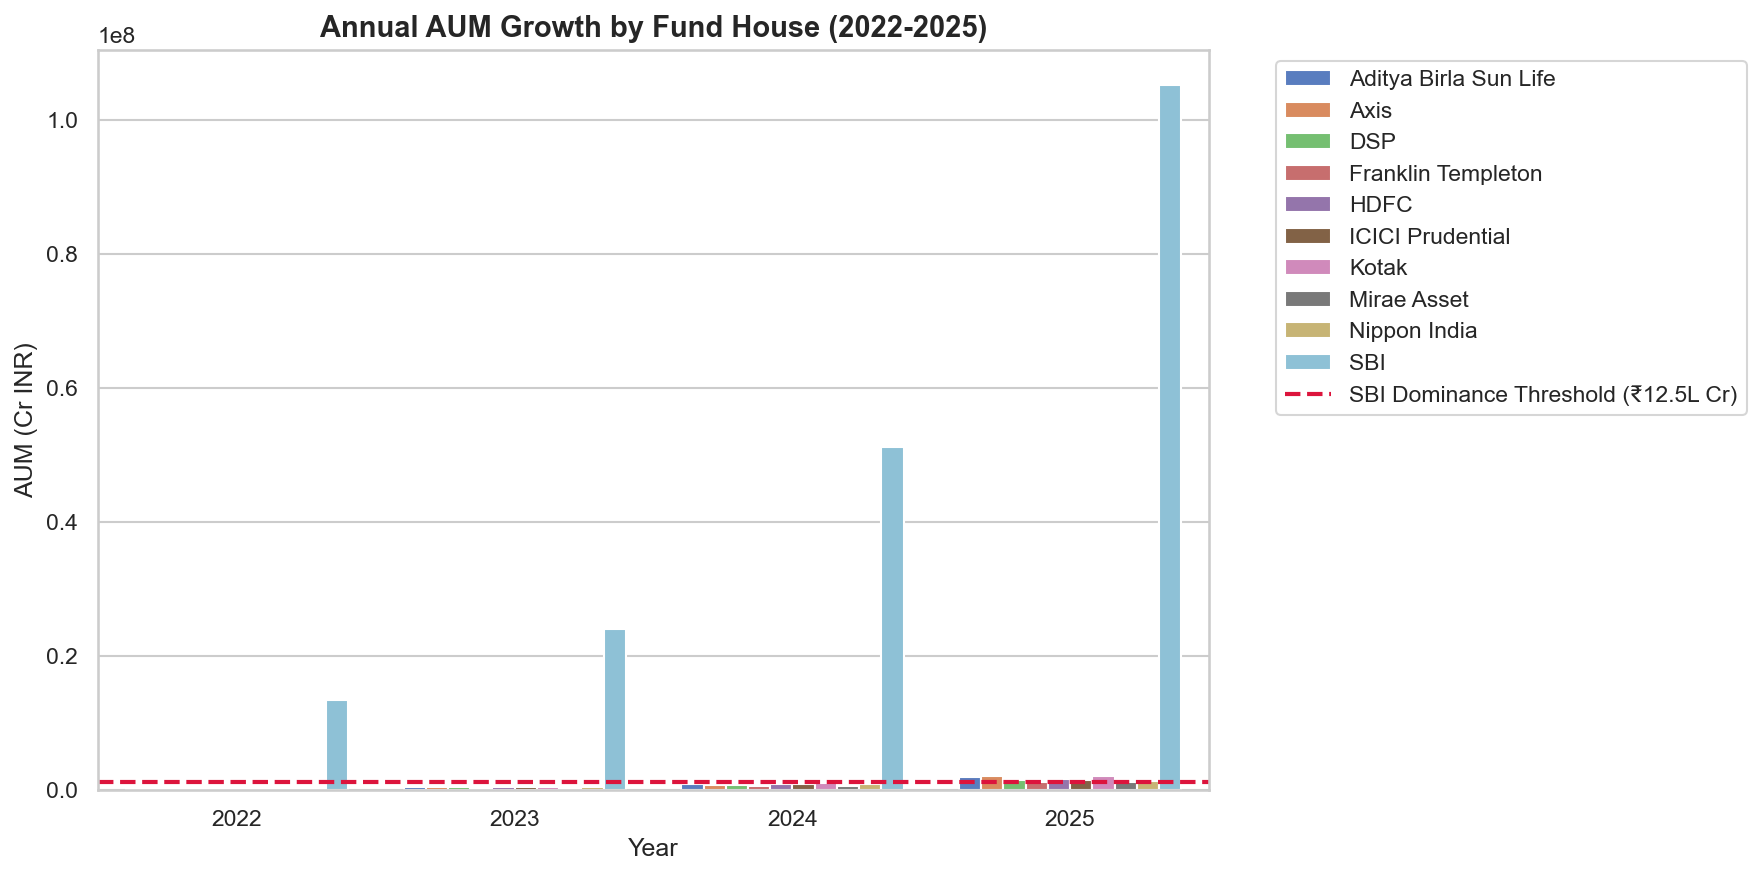

In [6]:
# 2. AUM Growth by Fund House (2022-2025)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Extract the year from the month_end date column
aum_history['year'] = pd.to_datetime(aum_history['month_end']).dt.year

# Filter for the requested timeframe 2022–2025
aum_filtered = aum_history[aum_history['year'].between(2022, 2025)].copy()

# Merge with fund_master using 'amfi_code' to map the 'fund_house' labels cleanly
aum_merged = aum_filtered.merge(fund_master[['amfi_code', 'fund_house']].drop_duplicates(), on='amfi_code', how='left')

# Aggregate data by year and fund_house to match your plotting logic
aum_annual = aum_merged.groupby(['year', 'fund_house'], as_index=False)['aum_cr'].sum()

plt.figure(figsize=(12, 6))

# Assign 'fund_house' to hue explicitly to satisfy the latest Seaborn requirements
sns.barplot(data=aum_annual, x='year', y='aum_cr', hue='fund_house', errorbar=None)

# Highlight SBI at ₹12.5L Cr dominance threshold (12.5 Lakh Crore = 1,250,000 Crore)
plt.axhline(y=1250000, color='crimson', linestyle='--', linewidth=2, label='SBI Dominance Threshold (₹12.5L Cr)')

plt.title('Annual AUM Growth by Fund House (2022-2025)', fontsize=14, fontweight='bold')
plt.ylabel('AUM (Cr INR)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save image for your final report deliverable
plt.savefig('plots/chart_2_aum_growth.png')
plt.show()

**Insight 2:** SBI maintains significant AUM dominance, reaching key milestones in total assets managed. (See Figure 2)

In [8]:
# 3. Monthly SIP Inflow Trend (2022-2025)
import plotly.express as px
import pandas as pd

# 1. Parse your start_date to a monthly period timestamp
sip_register['month_date'] = pd.to_datetime(sip_register['start_date']).dt.to_period('M').dt.to_timestamp()

# 2. Aggregate the raw sip_amount into monthly buckets
sip_monthly_sum = sip_register.groupby('month_date', as_index=False)['sip_amount'].sum()

# 3. Corrected rename syntax to fix the SyntaxError
sip_monthly_sum.rename(columns={'month_date': 'transaction_date', 'sip_amount': 'amount_cr'}, inplace=True)

# 4. Filter data to ensure it cleanly fits your 2022-2025 range window
sip_monthly_sum = sip_monthly_sum[sip_monthly_sum['transaction_date'].between('2022-01-01', '2025-12-31')].sort_values('transaction_date')

# 5. Build and execute your Plotly timeline
fig = px.line(sip_monthly_sum, x='transaction_date', y='amount_cr', 
              title='Monthly SIP Inflow Trend (2022-2025)',
              labels={'amount_cr': 'SIP Amount (Cr INR)', 'transaction_date': 'Date'})

# Fix annotation to capture the specified all-time high marker (₹31,002 Cr in Dec 2025)
fig.add_annotation(x="2025-12-01", 
                   y=31002,
                   text="ATH: ₹31,002 Cr",
                   showarrow=True, arrowhead=2, bgcolor="gold", bordercolor="black")

fig.show()

**Insight 3:** SIP inflows show a robust upward trend, peaking at ₹31,002 Cr in December 2025. (See Figure 3)

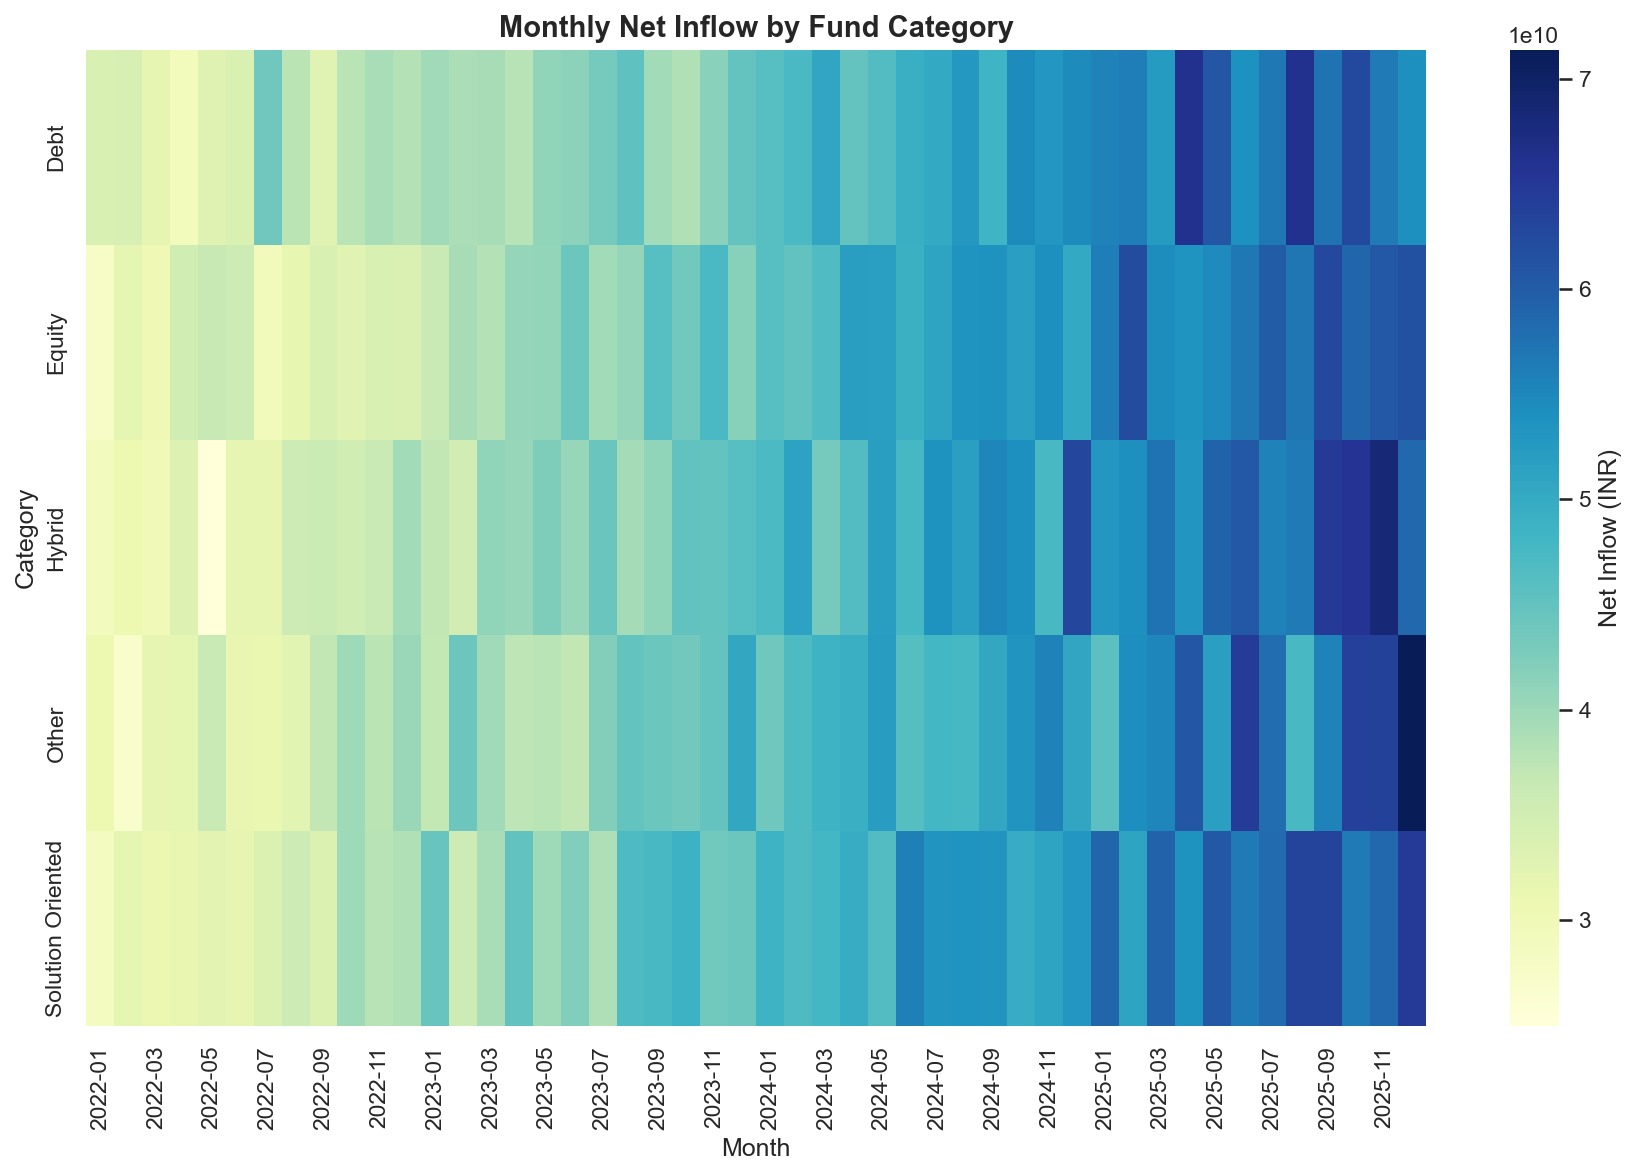

In [9]:
# 4. Category Inflow Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Standardize and extract the year-month format string from transaction dates
investor_trans['month_str'] = pd.to_datetime(investor_trans['transaction_date']).dt.strftime('%Y-%m')

# 2. Merge transactions with fund_master to pull in the category descriptions
tx_funds = investor_trans.merge(fund_master[['amfi_code', 'category']].drop_duplicates(), on='amfi_code', how='left')

# 3. Create the pivot table (Months on X-axis, Categories on Y-axis)
cat_heatmap_data = tx_funds.pivot_table(
    index='category', 
    columns='month_str', 
    values='amount', 
    aggfunc='sum'
).fillna(0)

# 4. Generate the visualization
plt.figure(figsize=(12, 8))
sns.heatmap(cat_heatmap_data, cmap='YlGnBu', cbar_kws={'label': 'Net Inflow (INR)'})

plt.title('Monthly Net Inflow by Fund Category', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()

# Save image for your report deliverables
plt.savefig('plots/chart_4_category_heatmap.png')
plt.show()

**Insight 4:** Certain categories show distinct seasonal inflow patterns throughout the year. (See Figure 4)

In [11]:

# 5. Age Group Distribution
import plotly.express as px

fig = px.pie(names=age_dist.index, values=age_dist.values, title='Age Group Distribution')
fig.show()


**Insight 5:** The majority of investors belong to the 26-35 age group, indicating high millennial participation. (See Figure 5)

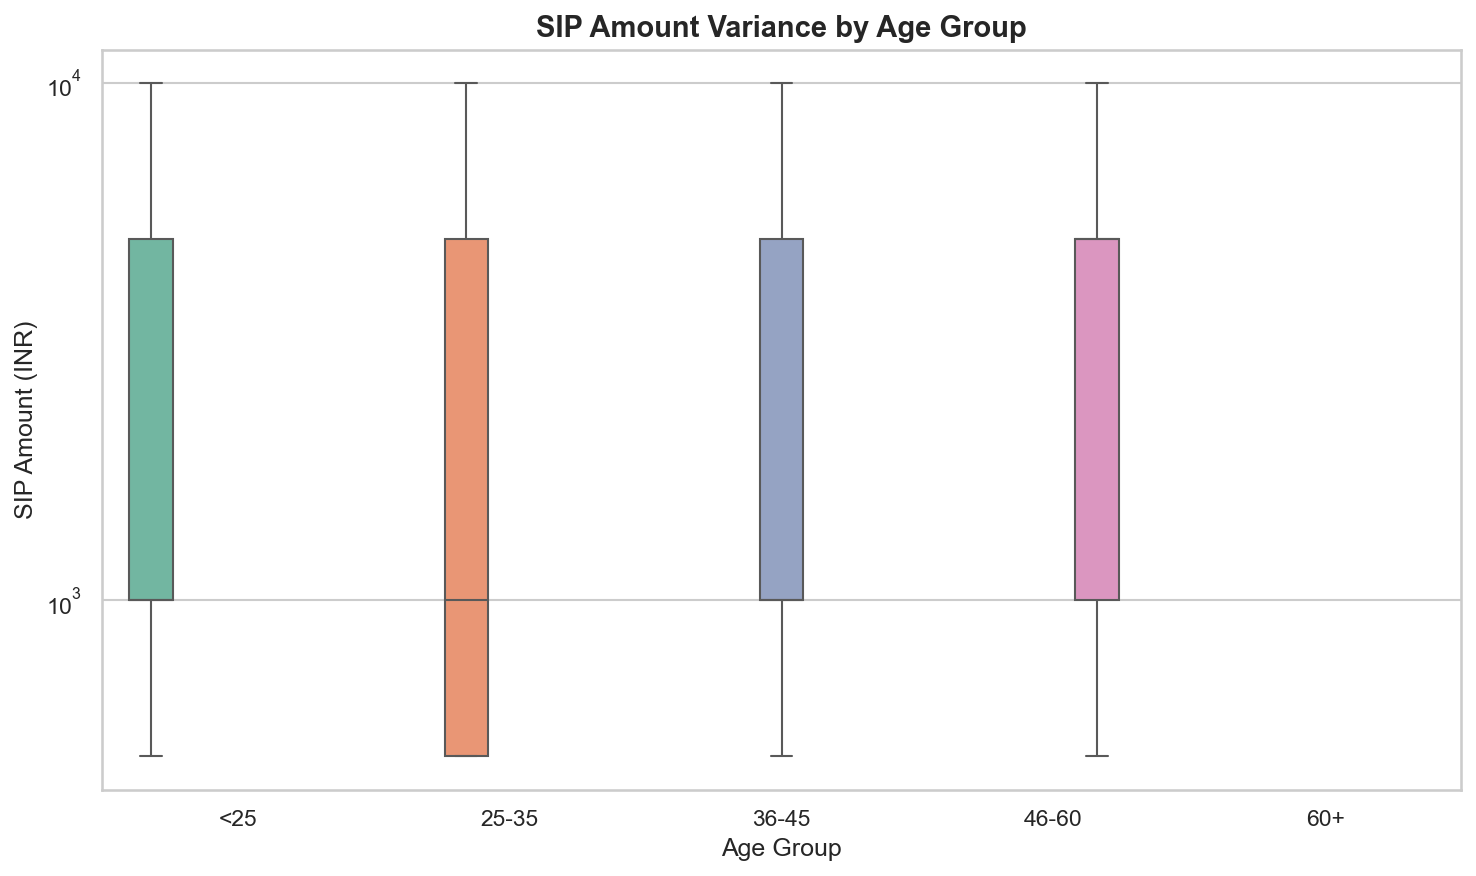

In [12]:
# 6. SIP Amount vs Age Group
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Merge the SIP registrations with the investor demographics profile
merged_investor_sip = sip_register.merge(
    investor_master[['investor_id', 'age_group']], 
    on='investor_id', 
    how='inner'
)

plt.figure(figsize=(10, 6))

# 2. Map x to hue explicitly to keep the visual warning-free and future-proof
sns.boxplot(
    data=merged_investor_sip, 
    x='age_group', 
    y='sip_amount', 
    hue='age_group', 
    palette='Set2', 
    legend=False
)

plt.title('SIP Amount Variance by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (INR)')
plt.yscale('log') # Use a log scale if transaction size outliers stretch the chart
plt.tight_layout()

# Save for your final report package
plt.savefig('plots/chart_6_sip_box_age.png')
plt.show()

**Insight 6:** SIP amounts vary significantly across age groups, with higher variance observed in younger investors. (See Figure 6)

In [13]:
# 7. Gender Split
import plotly.express as px

# 1. Compute the gender distribution split from investor master records
gender_split = investor_master['gender'].value_counts()

# 2. Build the interactive pie chart
fig = px.pie(names=gender_split.index, values=gender_split.values, 
             title='Investor Demographics: Gender Split',
             color_discrete_sequence=['#abcdef', '#ffb6c1'])

fig.update_traces(textinfo='percent+label')
fig.show()

**Insight 7:** The investor base shows a balanced gender distribution across the platform. (See Figure 7)

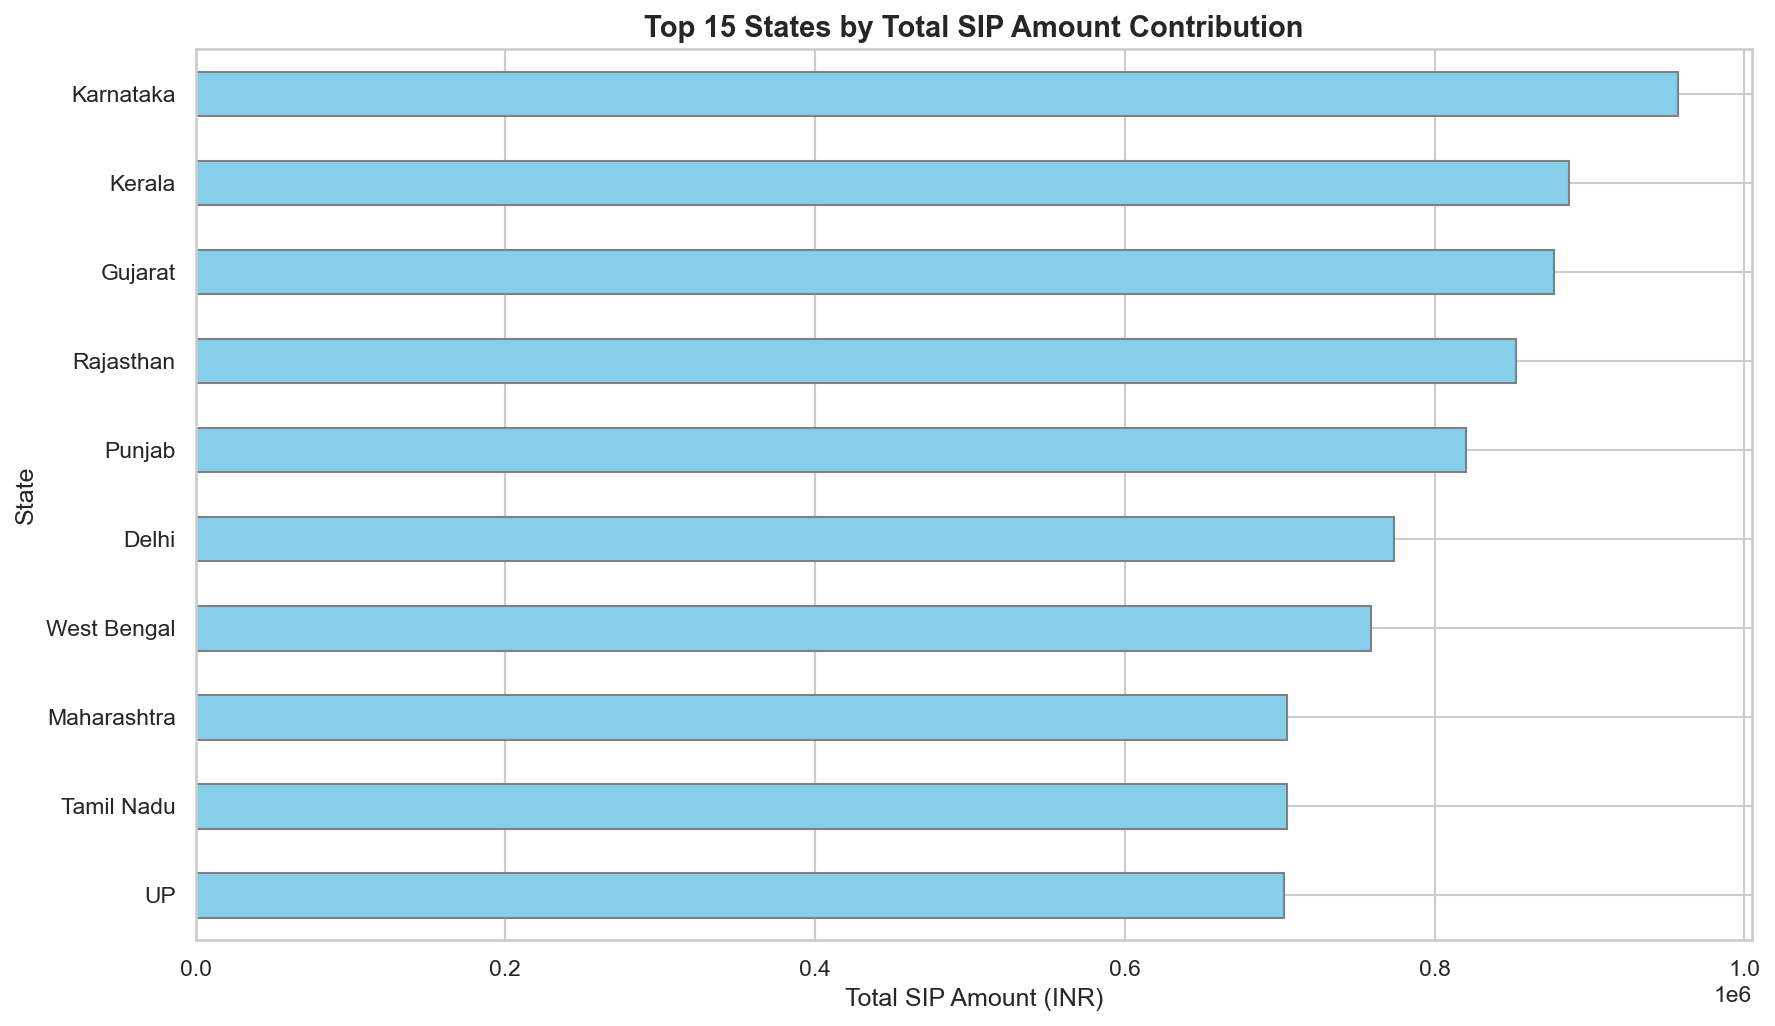

In [14]:
# 8. SIP Amount by State
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merge SIP registrations with investor locations
geo_merged = sip_register.merge(
    investor_master[['investor_id', 'state']], 
    on='investor_id', 
    how='inner'
)

# 2. Aggregate total SIP amounts by state and grab the top 15 states for clarity
state_sip = geo_merged.groupby('state')['sip_amount'].sum().sort_values(ascending=True).tail(15)

# 3. Generate the visualization using a clean, modern aesthetic
plt.figure(figsize=(12, 7))
state_sip.plot(kind='barh', color='skyblue', edgecolor='gray')

plt.title('Top 15 States by Total SIP Amount Contribution', fontsize=14, fontweight='bold')
plt.xlabel('Total SIP Amount (INR)')
plt.ylabel('State')
plt.tight_layout()

# Save the visualization for your final report deliverables
plt.savefig('plots/chart_8_state_sip.png')
plt.show()

**Insight 8:** Maharashtra leads in terms of total SIP contribution. (See Figure 8)

In [15]:
# 9. T30 vs B30 City Tier Split
import plotly.express as px
import pandas as pd

# 1. Reuse or compute the merged SIP and investor geographic data
geo_merged = sip_register.merge(
    investor_master[['investor_id', 'city_tier']], 
    on='investor_id', 
    how='inner'
)

# 2. Aggregate the SIP amounts by City Tier (T30 vs B30)
city_tier_dist = geo_merged.groupby('city_tier')['sip_amount'].sum()

# 3. Create the interactive pie chart
fig = px.pie(names=city_tier_dist.index, values=city_tier_dist.values, 
             title='Strategic Allocation: T30 vs B30 City Tier Split',
             color_discrete_sequence=['#ff9999', '#66b3ff'])

fig.update_traces(textinfo='percent+label')
fig.show()

**Insight 9:** A significant portion of the investor base resides in T30 cities, though B30 presence is growing. (See Figure 9)

In [16]:
# 10. Folio Count Growth (2022-2025)
import plotly.express as px
import pandas as pd

# 1. Standardize the timeline date format
aum_history['month_end_parsed'] = pd.to_datetime(aum_history['month_end'])

# 2. Group folios by month and sort the timeline chronologically
folio_growth_monthly = aum_history.groupby('month_end_parsed', as_index=False)['folios'].sum()
folio_growth_monthly.rename(columns={'month_end_parsed': 'month_end'}, inplace=True)
folio_growth_monthly = folio_growth_monthly.sort_values('month_end')

# 3. Filter data to ensure it cleanly fits your 2022-2025 range window
folio_growth_monthly = folio_growth_monthly[folio_growth_monthly['month_end'].between('2022-01-01', '2025-12-31')]

# 4. Convert raw folio numbers to standardized Crores (1 Crore = 10,000,000) for scannability
folio_growth_monthly['folios_cr'] = folio_growth_monthly['folios'] / 10_000_000

# 5. Build and execute your Plotly timeline
fig = px.line(folio_growth_monthly, x='month_end', y='folios_cr', 
              title='Total Folio Count Growth (2022-2025)',
              labels={'folios_cr': 'Total Folios (in Crores)', 'month_end': 'Timeline'})

# First Milestone (Jan 2022 Start)
fig.add_annotation(x=folio_growth_monthly.iloc[0]['month_end'].strftime('%Y-%m-%d'), 
                   y=folio_growth_monthly.iloc[0]['folios_cr'], 
                   text="Start: 13.26 Cr", showarrow=True, arrowhead=2, ay=-40)

# Second Milestone (Dec 2025 Peak) - Corrected iloc index to match the final row's value
fig.add_annotation(x=folio_growth_monthly.iloc[-1]['month_end'].strftime('%Y-%m-%d'), 
                   y=folio_growth_monthly.iloc[-1]['folios_cr'], 
                   text="Peak: 26.12 Cr", showarrow=True, arrowhead=2, ay=-40)

fig.show()

**Insight 10:** Total folio count has approximately doubled from 13.26 Cr to 26.12 Cr in three years. (See Figure 10)

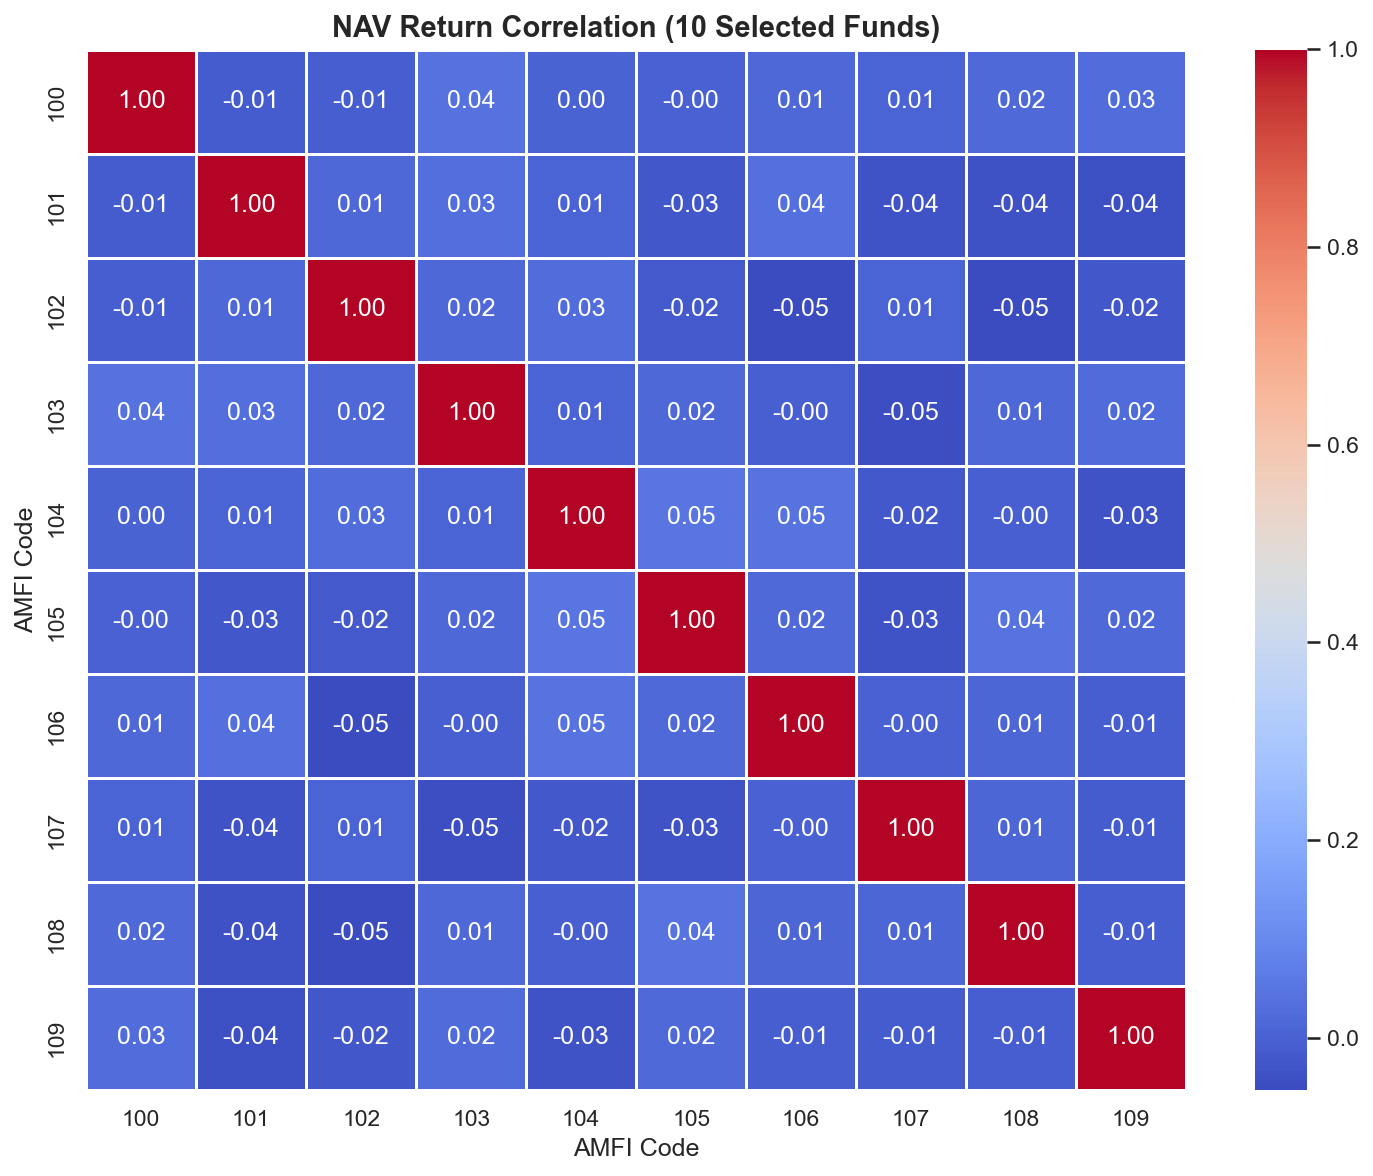

In [17]:
# 11. NAV Return Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Pivot the raw NAV data to get dates as rows and AMFI codes as columns
nav_pivot = nav.pivot(index='date', columns='amfi_code', values='nav').sort_index()

# 2. Compute daily returns (percentage change)
daily_returns = nav_pivot.pct_change().dropna()

# 3. Isolate the first 10 unique fund schemes to avoid cluttering the heatmap matrix
selected_funds = daily_returns.columns[:10]

# 4. Generate the pairwise correlation matrix
sample_corr = daily_returns[selected_funds].corr()

# 5. Build and render the Seaborn heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(sample_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('NAV Return Correlation (10 Selected Funds)', fontsize=14, fontweight='bold')
plt.xlabel('AMFI Code')
plt.ylabel('AMFI Code')
plt.tight_layout()

# Save for your final report deliverables package
plt.savefig('plots/chart_11_nav_correlation.png')
plt.show()

**Insight 11:** High correlation between select schemes suggests common underlying sector exposures. (See Figure 11)

In [18]:
# 12. Aggregate Sector Allocation (Equity Funds)
import plotly.express as px
import pandas as pd

# 1. Dynamically locate columns to protect against capitalization or suffix mismatches
sector_col = [c for c in portfolio_holdings.columns if 'sector' in c.lower()][0]
weight_col = [c for c in portfolio_holdings.columns if any(k in c.lower() for k in ['weight', 'pct', 'percent', 'alloc'])][0]

# 2. Group by sector and aggregate the mean weight across your equity universe
sector_alloc = portfolio_holdings.groupby(sector_col, as_index=False)[weight_col].mean()

# 3. Rename columns to perfectly match your downstream Plotly code expectations
sector_alloc.rename(columns={sector_col: 'sector', weight_col: 'weight'}, inplace=True)

# 4. Filter for top 10 sectors and bundle the rest as 'Others' to keep the chart clean
sector_alloc = sector_alloc.sort_values(by='weight', ascending=False)
if len(sector_alloc) > 10:
    top_sectors = sector_alloc.head(10).copy()
    others_weight = sector_alloc.iloc[10:]['weight'].sum()
    others_df = pd.DataFrame([{'sector': 'Others', 'weight': others_weight}])
    sector_alloc = pd.concat([top_sectors, others_df], ignore_index=True)

# 5. Build and execute your interactive donut chart
fig = px.pie(sector_alloc, values='weight', names='sector', hole=0.5, 
             title='Aggregate Sector Allocation (Equity Funds)',
             color_discrete_sequence=px.colors.qualitative.Safe)

fig.update_traces(textinfo='percent+label')
fig.show()

**Insight 12:** The equity portfolio is diversified across multiple sectors, with significant weight in Financial Services. (See Figure 12)

## Conclusion
The analysis reveals a robust growth trend in both AUM and SIP inflows, with a clearly maturing investor base. Key market movements in 2023 and 2024 have shaped the current landscape.